# AI Trading Bot Optimization: A Comparative Metaheuristic Analysis

---

## Project Overview
This notebook implements an advanced, AI-driven algorithmic trading bot for Bitcoin. It explores a highly complex 14-dimensional continuous parameter space to construct flexible composite technical signals (blending SMA, LMA, and EMA).

To navigate this non-convex, noisy financial landscape, we compare three distinct optimization paradigms against a Random Search baseline:
1. Simulated Annealing (SA): A single-state algorithm utilizing thermal agitation.
2. Antlion Optimizer (ALO): A population-based swarm intelligence algorithm.
3. Cuckoo Search (CS): An advanced population-based metaheuristic leveraging Lévy Flights.

---

### Experimental Workflow
1. Setup & Data Preparation: Load daily BTC prices and partition into Train and Test periods.
2. 14D Trading Engine: Construct the composite signal logic and backtesting environment (3% fee).
3. Algorithm Implementations: Introduce and code RS, SA, ALO, and CS sequentially.
4. Experiment: Convergence Analysis: Evaluate optimization trajectories on the training data (9,000 evaluations).
5. Experiment: Out-of-Sample Generalization: Deploy optimized parameters on the 2020+ market data and visualize trades for each algorithm.

## 1. Imports & Setup
We establish our environment and enforce a global random seed to guarantee strict scientific reproducibility across all stochastic processes.

In [31]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.special import gamma
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Global seed for strict academic reproducibility
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

## 2. Data Loading & Partitioning
We utilize Bitcoin daily close prices. To ensure rigorous evaluation of generalization capabilities, the dataset is strictly partitioned:

| Dataset | Date Range | Purpose |
|---------|------------|---------|
| Training | Pre-2020 | Fitness evaluation for algorithm optimization. |
| Testing | 2020 Onwards | Blind validation against unseen market volatility. |

In [32]:
def load_and_split_data(filepath='BTC-Daily.csv', split_date='2020-01-01'):
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Dataset {filepath} not found.")
        
    df = pd.read_csv(filepath)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)
    
    train_df = df[df['date'] < split_date].reset_index(drop=True)
    test_df = df[df['date'] >= split_date].reset_index(drop=True)
    
    return train_df, test_df

train_df, test_df = load_and_split_data()
train_prices = train_df['close'].values.astype(float)
test_prices = test_df['close'].values.astype(float)

print(f"Training Set: {len(train_prices)} days ({train_df['date'].min().date()} to {train_df['date'].max().date()})")
print(f"Testing Set:  {len(test_prices)} days ({test_df['date'].min().date()} to {test_df['date'].max().date()})")

Training Set: 1860 days (2014-11-28 to 2019-12-31)
Testing Set:  791 days (2020-01-01 to 2022-03-01)


## 3. The 14-Dimensional Trading Engine
We construct a highly complex parameter space by dynamically blending Simple (SMA), Linear (LMA), and Exponential (EMA) Moving Averages for both fast (HIGH) and slow (LOW) components.

Fitness is calculated by simulating trades with a 3% transaction fee, ensuring solutions reflect realistic profitability.

In [33]:
# --- Low-Level Filter Mathematics ---
def pad(P, N):
    if N <= 1: return P.copy()
    padding = 2.0 * P[0] - np.flip(P[1:N])
    return np.concatenate([padding, P])

def sma_kernel(N): return np.ones(N) / N
def lma_kernel(N): return (1.0 - np.arange(N)/N) * (2.0 / (N + 1))
def ema_kernel(N, alpha):
    alpha = float(np.clip(alpha, 1e-4, 1 - 1e-4))
    w = alpha * (1.0 - alpha) ** np.arange(N)
    return w / max(w.sum(), 1e-12)

def apply_filter(P, N, kernel):
    N = max(2, int(N))
    padded = pad(P, N)
    out = np.convolve(padded, kernel, 'valid')
    return out[: len(P)]

def apply_bounds(candidate, lb, ub):
    return np.clip(candidate, lb, ub)

# --- Composite Signal Generation ---
def build_composite_line(prices, w1, w2, w3, d1, d2, d3, alpha):
    d1, d2, d3 = int(d1), int(d2), int(d3)
    s1 = apply_filter(prices, d1, sma_kernel(d1))
    s2 = apply_filter(prices, d2, lma_kernel(d2))
    s3 = apply_filter(prices, d3, ema_kernel(d3, alpha))
    
    w_sum = abs(w1) + abs(w2) + abs(w3)
    if w_sum < 1e-12: return s1
    return (abs(w1)*s1 + abs(w2)*s2 + abs(w3)*s3) / w_sum

def generate_signals(prices, params):
    high_line = build_composite_line(prices, *params[0:7])
    low_line  = build_composite_line(prices, *params[7:14])
    
    diff = high_line - low_line
    sign_diff = np.sign(diff)
    
    buy_signals = np.zeros(len(prices), dtype=bool)
    sell_signals = np.zeros(len(prices), dtype=bool)
    
    for t in range(1, len(prices)):
        delta = sign_diff[t] - sign_diff[t - 1]
        if delta >= 1.5:   buy_signals[t] = True
        elif delta <= -1.5: sell_signals[t] = True
            
    return buy_signals, sell_signals, high_line, low_line

# --- Fitness Evaluator (Backtesting) ---
def evaluate_fitness(params, prices, initial_cash=1000.0, fee=0.03):
    buy_signals, sell_signals, _, _ = generate_signals(prices, params)
    cash, btc = float(initial_cash), 0.0
    
    for t in range(len(prices)):
        price = float(prices[t])
        if buy_signals[t] and cash > 0:
            btc = (cash * (1.0 - fee)) / price
            cash = 0.0
        elif sell_signals[t] and btc > 0:
            cash = btc * price * (1.0 - fee)
            btc = 0.0
            
    if btc > 0:
        cash = btc * prices[-1] * (1.0 - fee)
        
    return cash

In [34]:
# --- Multi-Segment Evaluation ---
# Split training data into 4 market-regime sub-windows
_seg_dates = train_df['date']
TRAIN_SEGMENTS = [
    train_prices[(_seg_dates < '2017-01-01').values],
    train_prices[((_seg_dates >= '2017-01-01') & (_seg_dates < '2018-01-01')).values],
    train_prices[((_seg_dates >= '2018-01-01') & (_seg_dates < '2019-01-01')).values],
    train_prices[(_seg_dates >= '2019-01-01').values],
]

def evaluate_fitness_multi(params, prices, initial_cash=1000.0, fee=0.03):
    scores = [evaluate_fitness(params, seg, initial_cash, fee) for seg in TRAIN_SEGMENTS]
    return np.mean(scores)

print(f"2014-2016 (sideways): {len(TRAIN_SEGMENTS[0])} days")
print(f"2017      (bull):     {len(TRAIN_SEGMENTS[1])} days")
print(f"2018      (bear):     {len(TRAIN_SEGMENTS[2])} days")
print(f"2019      (recovery): {len(TRAIN_SEGMENTS[3])} days")

2014-2016 (sideways): 765 days
2017      (bull):     365 days
2018      (bear):     365 days
2019      (recovery): 365 days


## 4. Random Search (RS) Baseline
To establish a foundation for our comparative analysis, we first implement a uniform Random Search algorithm. This acts as a control to prove that our metaheuristic algorithms possess genuine predictive power beyond mere chance in the 14-dimensional space.

In [35]:
def random_search(prices, bounds, max_evals, seed=GLOBAL_SEED, fitness_fn=None):
    if fitness_fn is None: fitness_fn = evaluate_fitness
    rng = np.random.default_rng(seed)
    lb, ub = np.array([b[0] for b in bounds]), np.array([b[1] for b in bounds])
    
    best_nest = rng.uniform(lb, ub)
    best_fitness = fitness_fn(best_nest, prices)
    history = [best_fitness]
    
    for _ in range(max_evals - 1):
        candidate = rng.uniform(lb, ub)
        f = fitness_fn(candidate, prices)
        if f > best_fitness:
            best_nest, best_fitness = candidate.copy(), f
        history.append(best_fitness)
        
    return best_nest, best_fitness, history

## 5. Simulated Annealing (SA)
Simulated Annealing represents the Single-State optimization class. It mimics the metallurgical cooling process. While it only explores one solution at a time (unlike swarm algorithms), it utilizes a "temperature" coefficient to probabilistically accept worse solutions, allowing it to climb out of shallow local optima.

In [36]:
def simulated_annealing(prices, bounds, max_evals, initial_temp=10000.0, cooling_rate=0.98, seed=GLOBAL_SEED, fitness_fn=None):
    if fitness_fn is None: fitness_fn = evaluate_fitness
    rng = np.random.default_rng(seed)
    lb, ub = np.array([b[0] for b in bounds]), np.array([b[1] for b in bounds])
    
    current_state = rng.uniform(lb, ub)
    current_fitness = fitness_fn(current_state, prices)
    best_state, best_fitness = current_state.copy(), current_fitness
    
    temp = initial_temp
    history = [best_fitness]
    
    for _ in range(max_evals - 1):
        neighbor = current_state + rng.normal(0, (ub - lb) * 0.05)
        neighbor = apply_bounds(neighbor, lb, ub)
        neighbor_fitness = fitness_fn(neighbor, prices)
        
        if neighbor_fitness > current_fitness:
            current_state, current_fitness = neighbor, neighbor_fitness
            if current_fitness > best_fitness:
                best_state, best_fitness = current_state.copy(), current_fitness
        else:
            diff = neighbor_fitness - current_fitness
            if rng.random() < math.exp(max(diff / temp, -700)):
                current_state, current_fitness = neighbor, neighbor_fitness
                
        temp *= cooling_rate
        history.append(best_fitness)
        
    return best_state, best_fitness, history

## 6. Antlion Optimizer (ALO)
ALO is a Population-Based swarm intelligence algorithm. It maintains multiple agents (ants and antlions). The search mechanism is driven by random walks around selected antlions, coupled with an adaptive boundary shrinking mechanism that forces the swarm to exploit promising regions as iterations progress.

In [37]:
def antlion_optimizer(prices, bounds, n_agents, max_iter, seed=GLOBAL_SEED, fitness_fn=None):
    if fitness_fn is None: fitness_fn = evaluate_fitness
    rng = np.random.default_rng(seed)
    dim, lb, ub = len(bounds), np.array([b[0] for b in bounds]), np.array([b[1] for b in bounds])
    
    antlions = rng.uniform(lb, ub, (n_agents, dim))
    al_fitness = np.array([fitness_fn(a, prices) for a in antlions])
    
    best_idx = np.argmax(al_fitness)
    elite, elite_fitness = antlions[best_idx].copy(), al_fitness[best_idx]
    history = []
    
    for t in range(max_iter):
        I = 10 ** (1 * (t / max_iter)) if t > max_iter * 0.1 else 1
        c, d = lb / I, ub / I
        
        ants = np.zeros_like(antlions)
        for i in range(n_agents):
            shifted_fit = al_fitness - np.min(al_fitness) + 1e-5
            selected_idx = rng.choice(n_agents, p=shifted_fit/shifted_fit.sum())
            selected_al = antlions[selected_idx]
            
            walk_towards_al = selected_al + rng.uniform(-1, 1, dim) * (d - c)
            walk_towards_elite = elite + rng.uniform(-1, 1, dim) * (d - c)
            ants[i] = apply_bounds((walk_towards_al + walk_towards_elite) / 2, lb, ub)
            
        ant_fitness = np.array([fitness_fn(a, prices) for a in ants])
        
        combined = np.vstack((antlions, ants))
        combined_fit = np.concatenate((al_fitness, ant_fitness))
        top_idx = np.argsort(combined_fit)[-n_agents:]
        
        antlions, al_fitness = combined[top_idx], combined_fit[top_idx]
        if al_fitness[-1] > elite_fitness:
            elite, elite_fitness = antlions[-1].copy(), al_fitness[-1]
            
        history.extend([elite_fitness] * n_agents)
        
    return elite, elite_fitness, history

## 7. Cuckoo Search (CS)
Cuckoo Search is an advanced population-based algorithm renowned for its use of Lévy Flights—a probability distribution with infinite variance. While financial noise can easily trap algorithms like SA or cause ALO to prematurely converge, the heavy-tailed random walks of CS enable sudden, massive leaps in the parameter space, offering unparalleled global exploration capabilities.

In [38]:
def cuckoo_search(prices, bounds, n_nests, max_iter, pa=0.25, seed=GLOBAL_SEED, fitness_fn=None):
    if fitness_fn is None: fitness_fn = evaluate_fitness
    rng = np.random.default_rng(seed)
    dim, lb, ub = len(bounds), np.array([b[0] for b in bounds]), np.array([b[1] for b in bounds])
    
    nests = rng.uniform(lb, ub, (n_nests, dim))
    fitness = np.array([fitness_fn(n, prices) for n in nests])
    
    best_idx = np.argmax(fitness)
    best_nest, best_fitness = nests[best_idx].copy(), fitness[best_idx]
    history = []
    
    beta = 1.5
    sigma = (gamma(1 + beta) * math.sin(math.pi * beta / 2) / 
             (gamma((1 + beta) / 2) * beta * 2**((beta - 1) / 2))) ** (1 / beta)
             
    for t in range(max_iter):
        for i in range(n_nests):
            u, v = rng.normal(0, sigma, dim), rng.normal(0, 1, dim)
            step = u / (np.abs(v) ** (1 / beta))
            stepsize = 0.05 * step * (nests[i] - best_nest)
            
            new_nest = apply_bounds(nests[i] + stepsize * rng.standard_normal(dim), lb, ub)
            f_new = fitness_fn(new_nest, prices)
            
            j = rng.integers(0, n_nests)
            if f_new > fitness[j]:
                nests[j], fitness[j] = new_nest, f_new
                if f_new > best_fitness:
                    best_nest, best_fitness = new_nest.copy(), f_new
            history.append(best_fitness)
                    
        K = rng.random((n_nests, dim)) < pa
        step_discovery = rng.random((n_nests, dim)) * (nests[rng.permutation(n_nests)] - nests[rng.permutation(n_nests)])
        new_nests_discovery = apply_bounds(nests + K * step_discovery, lb, ub)
        
        for i in range(n_nests):
            f_new_disc = fitness_fn(new_nests_discovery[i], prices)
            if f_new_disc > fitness[i]:
                nests[i], fitness[i] = new_nests_discovery[i], f_new_disc
                if f_new_disc > best_fitness:
                    best_nest, best_fitness = nests[i].copy(), f_new_disc
            history.append(best_fitness)
        
    return best_nest, best_fitness, history

## 8. Experiment: Convergence Analysis on Training Data
We allocate exactly 9,000 evaluations to each algorithm to strictly observe their capability to exploit the 14-dimensional search space on the training data (pre-2020).

Parameter Space Bounds:
All moving average window sizes are given full freedom between [2.0, 100.0] to ensure maximum flexibility.

- SA: 9,000 sequential iterations.
- ALO: 30 agents $\times$ 300 iterations = 9,000 evaluations.
- CS: 30 nests $\times$ 150 iterations (2 evaluation phases per iteration = 9,000 evaluations).
- RS: 9,000 random evaluations.

In [ ]:
# Fully Unconstrained 14D Parameter Space
BOUNDS_14D = [
    (0.01, 1.0), (0.01, 1.0), (0.01, 1.0), (2.0, 40.0), (2.0, 40.0), (2.0, 40.0), (0.01, 0.99), # HIGH Component
    (0.01, 1.0), (0.01, 1.0), (0.01, 1.0), (21.0, 100.0), (21.0, 100.0), (21.0, 100.0), (0.01, 0.99)  # LOW Component
]

BUDGET = 9000

sa_params, sa_train, sa_hist = simulated_annealing(train_prices, BOUNDS_14D, max_evals=BUDGET)

alo_params, alo_train, alo_hist = antlion_optimizer(train_prices, BOUNDS_14D, n_agents=30, max_iter=300)

cs_params, cs_train, cs_hist = cuckoo_search(train_prices, BOUNDS_14D, n_nests=30, max_iter=150)

rs_params, rs_train, rs_hist = random_search(train_prices, BOUNDS_14D, max_evals=BUDGET)

print("\nOptimization Complete.")


Optimization Complete.


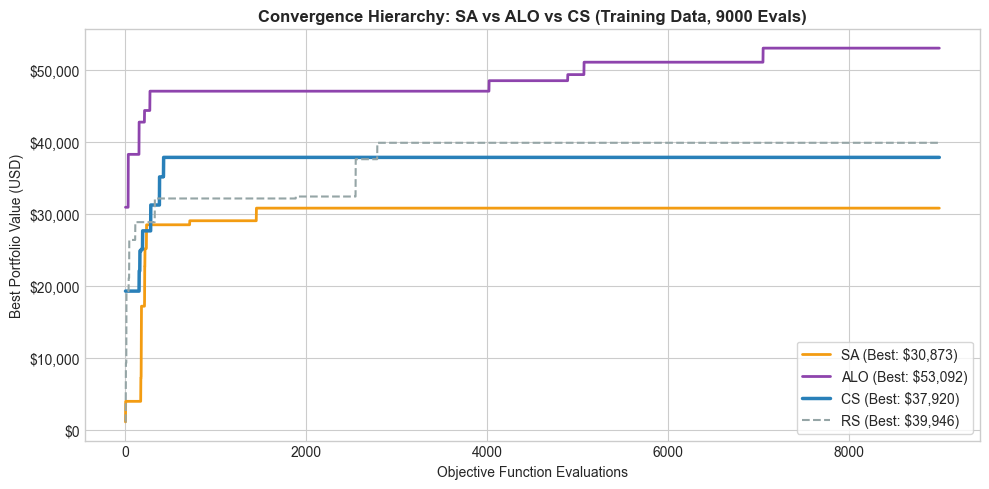

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(np.linspace(0, BUDGET, len(sa_hist)), sa_hist, label=f'SA (Best: ${sa_train:,.0f})', color='#f39c12', linewidth=2)
ax.plot(np.linspace(0, BUDGET, len(alo_hist)), alo_hist, label=f'ALO (Best: ${alo_train:,.0f})', color='#8e44ad', linewidth=2)
ax.plot(np.linspace(0, BUDGET, len(cs_hist)), cs_hist, label=f'CS (Best: ${cs_train:,.0f})', color='#2980b9', linewidth=2.5)
ax.plot(np.linspace(0, BUDGET, len(rs_hist)), rs_hist, label=f'RS (Best: ${rs_train:,.0f})', color='#95a5a6', linewidth=1.5, linestyle='--')

ax.set_xlabel('Objective Function Evaluations')
ax.set_ylabel('Best Portfolio Value (USD)')
ax.set_title('Convergence Hierarchy: SA vs ALO vs CS (Training Data, 9000 Evals)', fontweight='bold')
ax.legend(frameon=True, facecolor='white')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
plt.tight_layout()
plt.show()

## 9. Experiment: Out-of-Sample Generalization (Test Set)
We now deploy the parameters discovered by all algorithms onto the highly volatile 2020 - 2026 market data. Because metaheuristics are stochastic, performance depends on both the topology of the search space and the algorithmic mechanisms. This out-of-sample test determines the true predictive and generalization capability of the solutions.

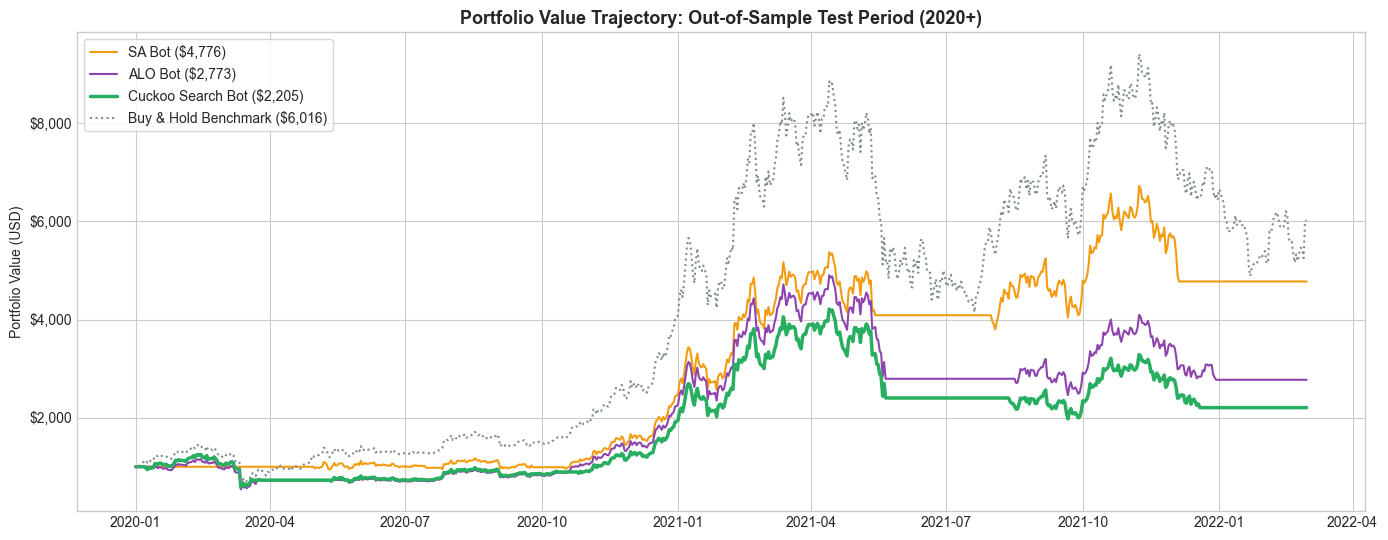

In [41]:
INITIAL_CASH = 1000.0

sa_test_val = evaluate_fitness(sa_params, test_prices, initial_cash=INITIAL_CASH)
alo_test_val = evaluate_fitness(alo_params, test_prices, initial_cash=INITIAL_CASH)
cs_test_val = evaluate_fitness(cs_params, test_prices, initial_cash=INITIAL_CASH)
bh_test_val = INITIAL_CASH * (test_prices[-1] / test_prices[0])

def simulate_portfolio_curve(params, prices, initial_cash=1000.0, fee=0.03):
    buy_signals, sell_signals, _, _ = generate_signals(prices, params)
    cash, btc = float(initial_cash), 0.0
    portfolio = []
    for t in range(len(prices)):
        price = float(prices[t])
        if buy_signals[t] and cash > 0:
            btc, cash = (cash * (1.0 - fee)) / price, 0.0
        elif sell_signals[t] and btc > 0:
            cash, btc = btc * price * (1.0 - fee), 0.0
        portfolio.append(cash + btc * price)
    return np.array(portfolio)

sa_curve = simulate_portfolio_curve(sa_params, test_prices)
alo_curve = simulate_portfolio_curve(alo_params, test_prices)
cs_curve = simulate_portfolio_curve(cs_params, test_prices)
bh_curve = INITIAL_CASH * (test_prices / test_prices[0])

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(test_df['date'], sa_curve, label=f'SA Bot (${sa_test_val:,.0f})', color='#f39c12', linewidth=1.5)
ax.plot(test_df['date'], alo_curve, label=f'ALO Bot (${alo_test_val:,.0f})', color='#8e44ad', linewidth=1.5)
ax.plot(test_df['date'], cs_curve, label=f'Cuckoo Search Bot (${cs_test_val:,.0f})', color='#27ae60', linewidth=2.5)
ax.plot(test_df['date'], bh_curve, label=f'Buy & Hold Benchmark (${bh_test_val:,.0f})', color='#7f8c8d', linestyle=':', linewidth=1.5)

ax.set_title('Portfolio Value Trajectory: Out-of-Sample Test Period (2020+)', fontsize=13, fontweight='bold')
ax.set_ylabel('Portfolio Value (USD)')
ax.legend(frameon=True, facecolor='white')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
plt.tight_layout()
plt.show()

### Visualizing the 14D Trade Signals per Algorithm
The following charts unbox the parameters discovered by each algorithm, revealing how the HIGH composite line interacts with the LOW composite line to generate strategic trading points.

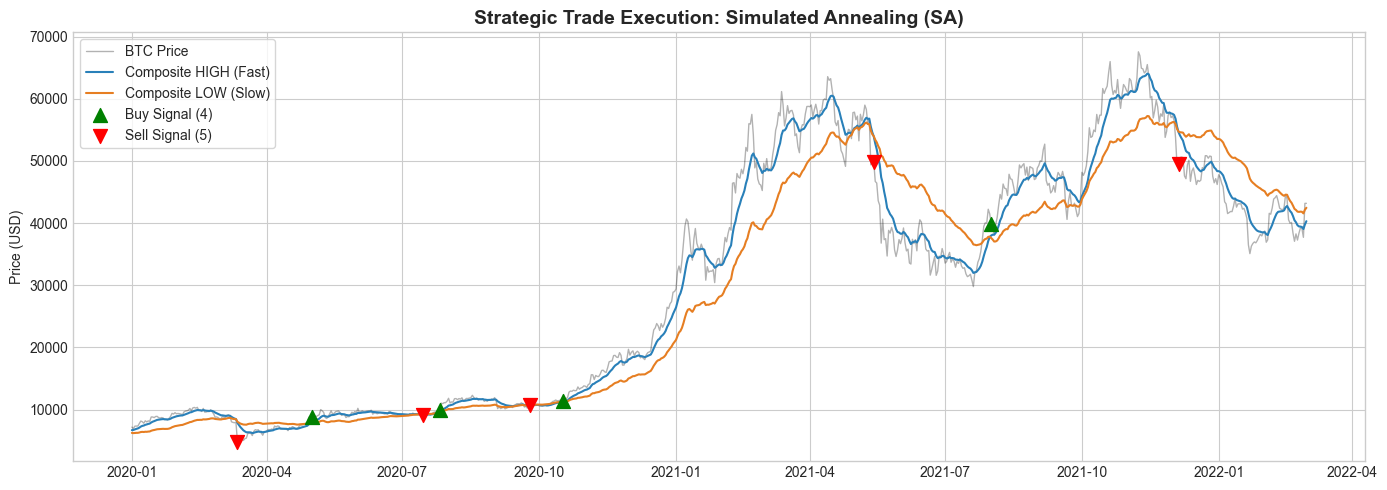

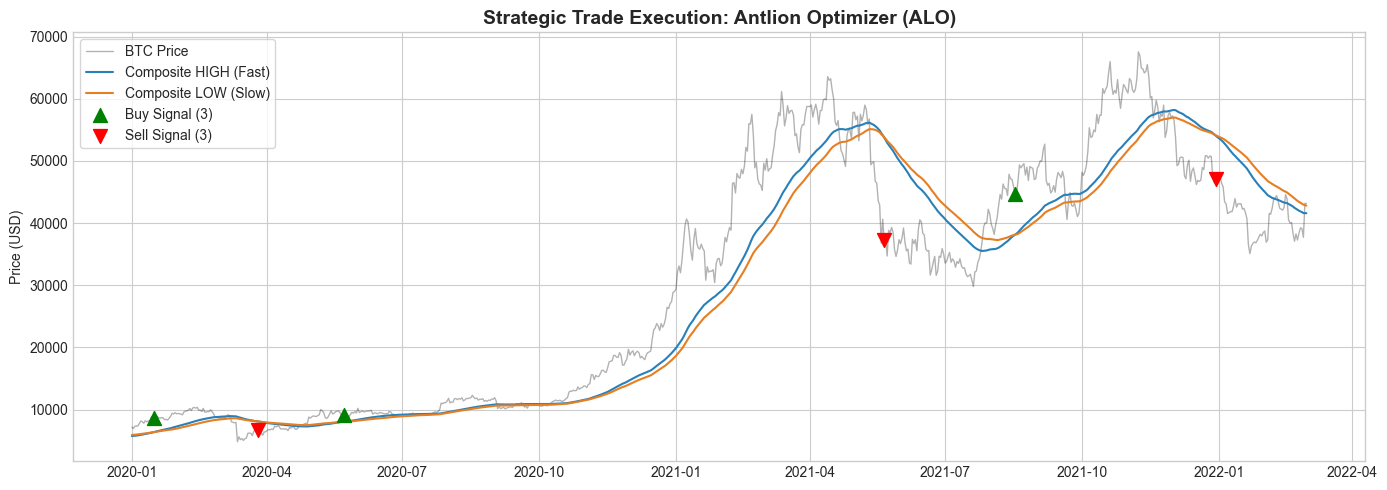

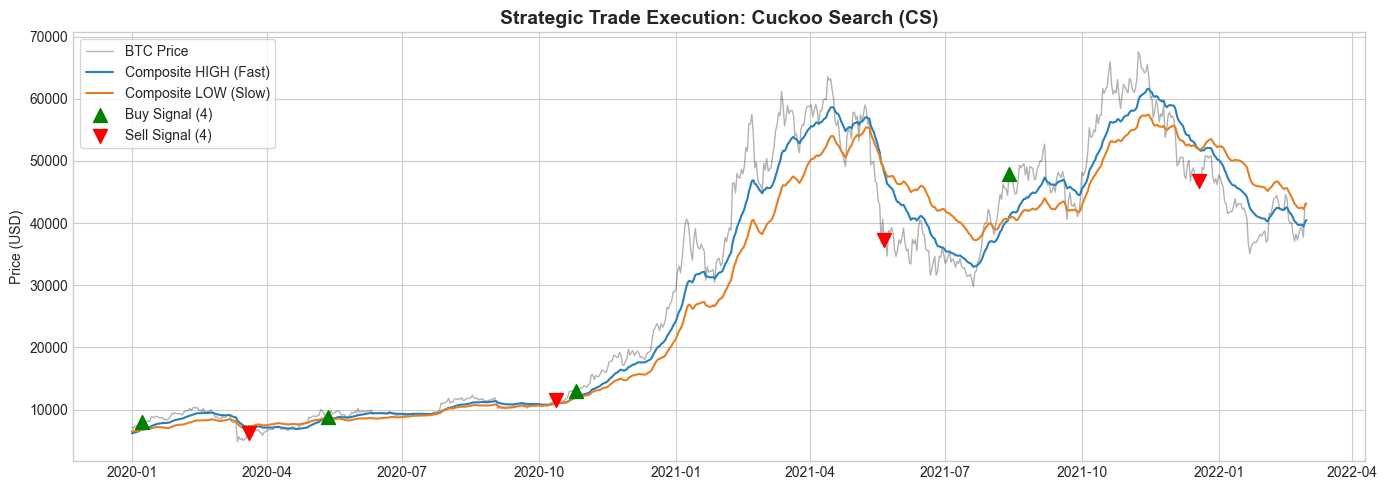

In [42]:
def plot_trade_signals(prices, dates, params, algo_name):
    buy_sigs, sell_sigs, high_line, low_line = generate_signals(prices, params)
    buy_idx = np.where(buy_sigs)[0]
    sell_idx = np.where(sell_sigs)[0]

    fig, ax = plt.subplots(figsize=(14, 5))
    
    # Standardized colors for identical comparative analysis
    ax.plot(dates, prices, label='BTC Price', color='black', alpha=0.3, linewidth=1)
    ax.plot(dates, high_line, label='Composite HIGH (Fast)', color='#2980b9', linewidth=1.5) # Blue
    ax.plot(dates, low_line, label='Composite LOW (Slow)', color='#e67e22', linewidth=1.5)  # Orange

    ax.scatter(dates[buy_idx], prices[buy_idx], marker='^', color='green', s=100, zorder=5, label=f'Buy Signal ({len(buy_idx)})')
    ax.scatter(dates[sell_idx], prices[sell_idx], marker='v', color='red', s=100, zorder=5, label=f'Sell Signal ({len(sell_idx)})')

    ax.set_title(f'Strategic Trade Execution: {algo_name}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Price (USD)')
    ax.legend(loc='upper left', frameon=True, facecolor='white')
    plt.tight_layout()
    plt.show()

# Visualize execution for all algorithms identically
plot_trade_signals(test_prices, test_df['date'].values, sa_params, 'Simulated Annealing (SA)')
plot_trade_signals(test_prices, test_df['date'].values, alo_params, 'Antlion Optimizer (ALO)')
plot_trade_signals(test_prices, test_df['date'].values, cs_params, 'Cuckoo Search (CS)')

## 10. Executive Summary

In [43]:
summary = pd.DataFrame({
    'Strategy / Algorithm': ['Simulated Annealing', 'Antlion Optimizer', 'Cuckoo Search', 'Buy & Hold'],
    'Training Final Value': [f'${sa_train:,.2f}', f'${alo_train:,.2f}', f'${cs_train:,.2f}', 'N/A'],
    'Testing Final Value': [f'${sa_test_val:,.2f}', f'${alo_test_val:,.2f}', f'${cs_test_val:,.2f}', f'${bh_test_val:,.2f}'],
    'Out-of-Sample ROI (%)': [f'{((sa_test_val-INITIAL_CASH)/INITIAL_CASH)*100:.1f}%', 
                              f'{((alo_test_val-INITIAL_CASH)/INITIAL_CASH)*100:.1f}%', 
                              f'{((cs_test_val-INITIAL_CASH)/INITIAL_CASH)*100:.1f}%', 
                              f'{((bh_test_val-INITIAL_CASH)/INITIAL_CASH)*100:.1f}%']
})

print(summary.to_string(index=False, justify='center'))

Strategy / Algorithm Training Final Value Testing Final Value Out-of-Sample ROI (%)
Simulated Annealing       $30,872.92           $4,776.36              377.6%       
  Antlion Optimizer       $53,091.72           $2,772.97              177.3%       
      Cuckoo Search       $37,920.02           $2,205.11              120.5%       
         Buy & Hold              N/A           $6,015.80              501.6%       


## 11. Experiment: Multi-Segment Optimisation
Re-running all algorithms with `evaluate_fitness_multi` as the fitness function.  
Each candidate is evaluated on all four market-regime segments; the **average** portfolio value is returned.  
This forces the optimizer to find parameters that generalise across bull, bear, and sideways conditions.

In [44]:
BUDGET = 9000

print("Running SA  (multi-segment)...")
sa_ms_params, _, sa_ms_hist  = simulated_annealing(
    train_prices, BOUNDS_14D, max_evals=BUDGET, fitness_fn=evaluate_fitness_multi)

print("Running ALO (multi-segment)...")
alo_ms_params, _, alo_ms_hist = antlion_optimizer(
    train_prices, BOUNDS_14D, n_agents=30, max_iter=300, fitness_fn=evaluate_fitness_multi)

print("Running CS  (multi-segment)...")
cs_ms_params, _, cs_ms_hist  = cuckoo_search(
    train_prices, BOUNDS_14D, n_nests=30, max_iter=150, fitness_fn=evaluate_fitness_multi)

print("Running RS  (multi-segment)...")
rs_ms_params, _, rs_ms_hist  = random_search(
    train_prices, BOUNDS_14D, max_evals=BUDGET, fitness_fn=evaluate_fitness_multi)

# Evaluate on full training set (single sequence) for fair comparison
sa_ms_train  = evaluate_fitness(sa_ms_params,  train_prices)
alo_ms_train = evaluate_fitness(alo_ms_params, train_prices)
cs_ms_train  = evaluate_fitness(cs_ms_params,  train_prices)

print("\nDone.")

Running SA  (multi-segment)...
Running ALO (multi-segment)...
Running CS  (multi-segment)...
Running RS  (multi-segment)...

Done.


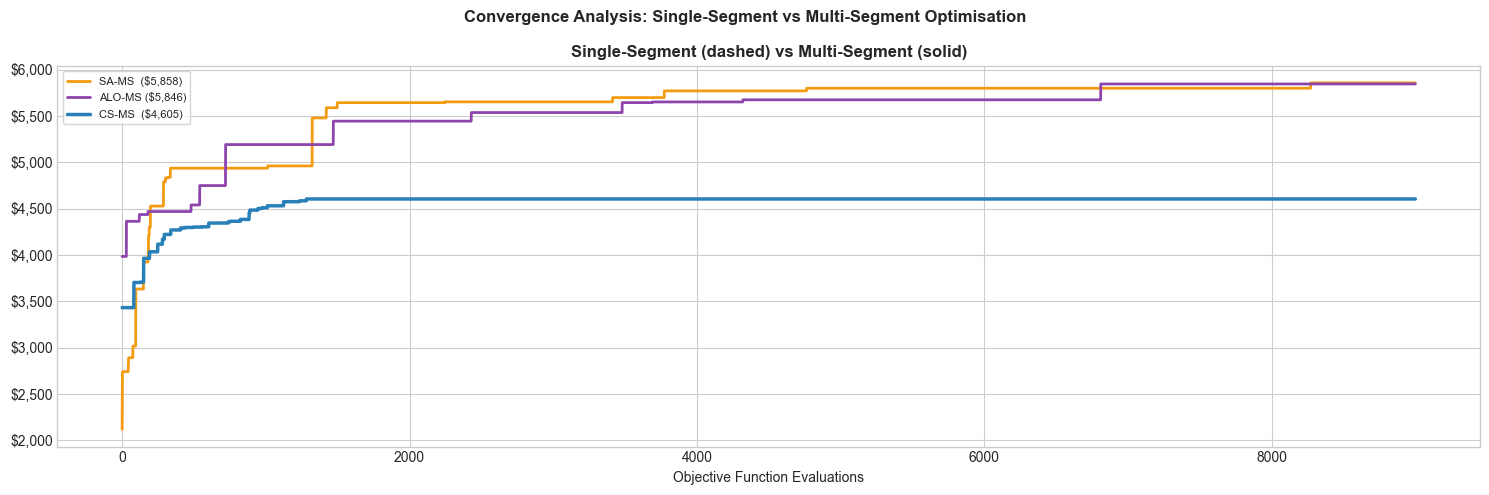

In [49]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(np.linspace(0, BUDGET, len(sa_ms_hist)),  sa_ms_hist,  label=f'SA-MS  (${max(sa_ms_hist):,.0f})',  color='#f39c12', linewidth=2)
ax.plot(np.linspace(0, BUDGET, len(alo_ms_hist)), alo_ms_hist, label=f'ALO-MS (${max(alo_ms_hist):,.0f})', color='#8e44ad', linewidth=2)
ax.plot(np.linspace(0, BUDGET, len(cs_ms_hist)),  cs_ms_hist,  label=f'CS-MS  (${max(cs_ms_hist):,.0f})',  color='#2980b9', linewidth=2.5)
ax.set_xlabel('Objective Function Evaluations')
ax.set_title('Single-Segment (dashed) vs Multi-Segment (solid)', fontweight='bold')
ax.legend(frameon=True, facecolor='white', fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))

plt.suptitle('Convergence Analysis: Single-Segment vs Multi-Segment Optimisation', fontweight='bold')
plt.tight_layout()
plt.show()

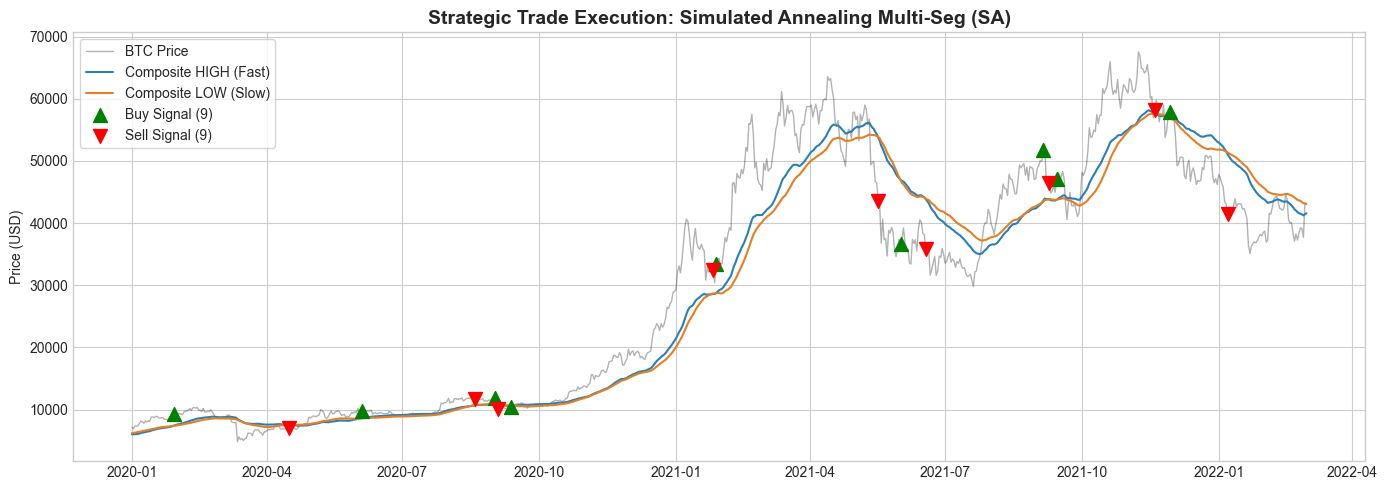

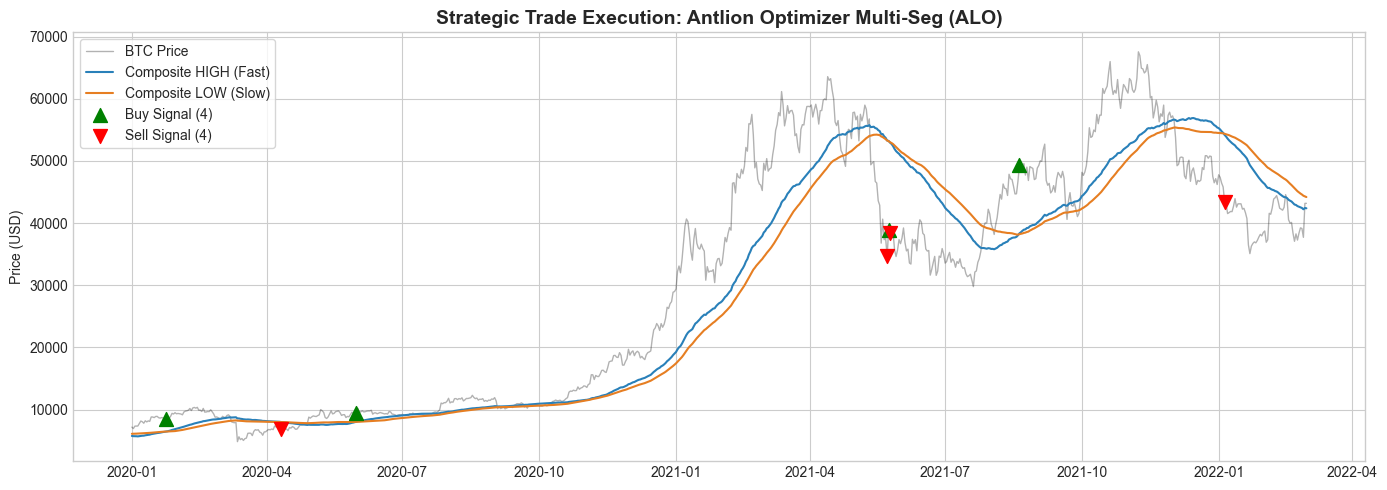

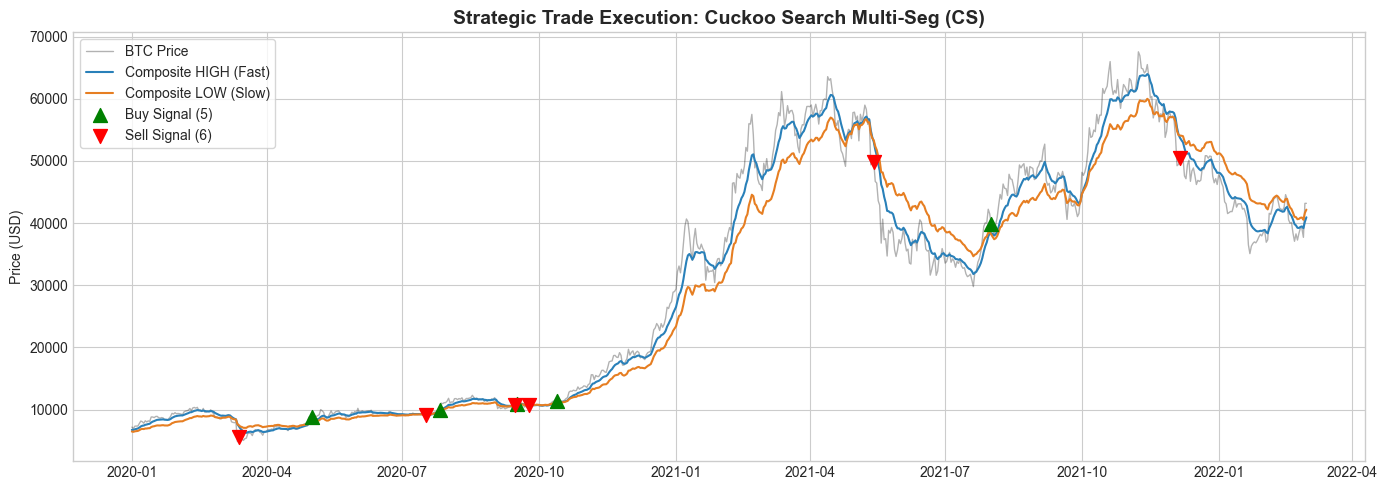

In [50]:
# Visualize execution for all algorithms identically
plot_trade_signals(test_prices, test_df['date'].values, sa_ms_params, 'Simulated Annealing Multi-Seg (SA)')
plot_trade_signals(test_prices, test_df['date'].values, alo_ms_params, 'Antlion Optimizer Multi-Seg (ALO)')
plot_trade_signals(test_prices, test_df['date'].values, cs_ms_params, 'Cuckoo Search Multi-Seg (CS)')

## 12. Comparison: Single-Sequence vs Multi-Segment

 Algorithm Original Train ($) Multi-Seg Train ($) Original Test ($) Multi-Seg Test ($)
        SA            $30,873              $8,058            $4,776             $1,422
       ALO            $53,092             $38,419            $2,773             $2,046
        CS            $37,920             $28,530            $2,205             $4,505
Buy & Hold                N/A                 N/A            $6,016             $6,016


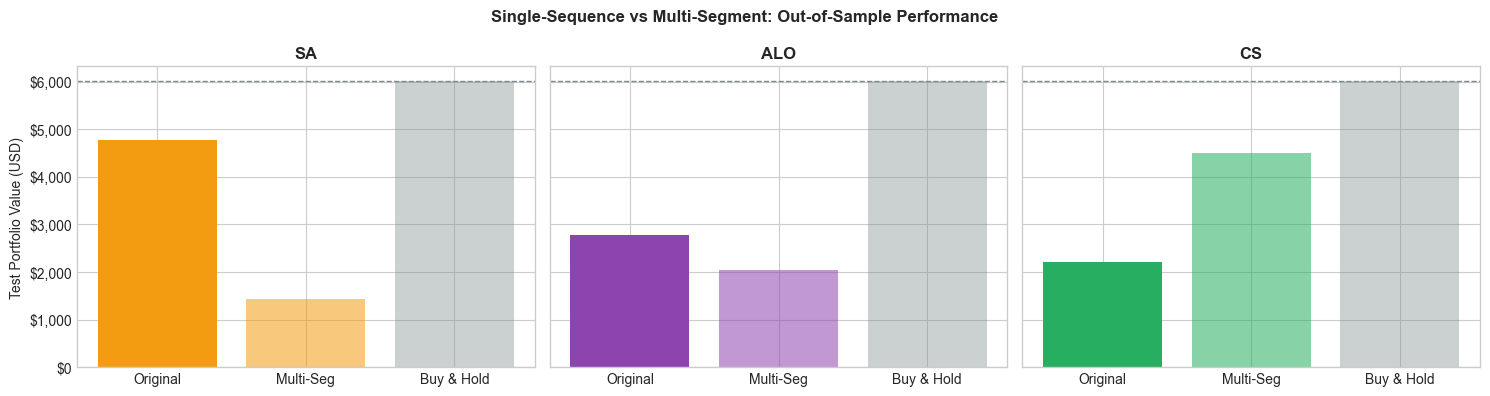

In [46]:
sa_ms_test  = evaluate_fitness(sa_ms_params,  test_prices, initial_cash=INITIAL_CASH)
alo_ms_test = evaluate_fitness(alo_ms_params, test_prices, initial_cash=INITIAL_CASH)
cs_ms_test  = evaluate_fitness(cs_ms_params,  test_prices, initial_cash=INITIAL_CASH)

comparison = pd.DataFrame({
    'Algorithm':           ['SA',                 'ALO',                'CS',                'Buy & Hold'],
    'Original Train ($)':  [f'${sa_train:,.0f}',  f'${alo_train:,.0f}', f'${cs_train:,.0f}', 'N/A'],
    'Multi-Seg Train ($)': [f'${sa_ms_train:,.0f}',f'${alo_ms_train:,.0f}',f'${cs_ms_train:,.0f}','N/A'],
    'Original Test ($)':   [f'${sa_test_val:,.0f}',f'${alo_test_val:,.0f}',f'${cs_test_val:,.0f}',f'${bh_test_val:,.0f}'],
    'Multi-Seg Test ($)':  [f'${sa_ms_test:,.0f}', f'${alo_ms_test:,.0f}', f'${cs_ms_test:,.0f}', f'${bh_test_val:,.0f}'],
})
print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
algos = [('SA',  sa_test_val,  sa_ms_test,  '#f39c12'),
         ('ALO', alo_test_val, alo_ms_test, '#8e44ad'),
         ('CS',  cs_test_val,  cs_ms_test,  '#27ae60')]

for ax, (name, orig, ms, color) in zip(axes, algos):
    bars = ax.bar(['Original', 'Multi-Seg', 'Buy & Hold'],
                  [orig, ms, bh_test_val],
                  color=[color, color, '#7f8c8d'])
    bars[1].set_alpha(0.55)
    bars[2].set_alpha(0.4)
    ax.set_title(name, fontweight='bold')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
    ax.axhline(bh_test_val, color='#7f8c8d', linestyle='--', linewidth=1)

axes[0].set_ylabel('Test Portfolio Value (USD)')
plt.suptitle('Single-Sequence vs Multi-Segment: Out-of-Sample Performance', fontweight='bold')
plt.tight_layout()
plt.show()